# Tutorial 2 — Estimation: from an estimand to a number

[Tutorial 1](01_identification.ipynb) turned causal graphs into *estimands*. This one
estimates those estimands from data and checks every answer against a known ground
truth. The single entry point is

```python
est_general.estimate_case_by_case(G, X, Y, y_val, obs_data, cluster_variables=[...])
```

It inspects the graph, routes to the matching estimator, and returns estimates keyed
by method and treatment value. We walk **four graphs of increasing difficulty**:

1. a **back-door** graph — all three estimators (OM / IPW / DML);
2. a **multi-treatment sequential (mSBD)** graph — effects of a joint `do(X1, X2)`;
3. the **Napkin** graph — a ratio-form c-component effect, estimated by a dedicated
   ratio estimator with **all three** estimators;
4. a **front-door** graph — estimated through the general c-component machinery,
   which runs in outcome-model-only mode.

Because every example is a full structural causal model, we can always compare to the
true `P(Y=1 | do(X=x))`.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))
import warnings; warnings.filterwarnings('ignore')
%matplotlib inline

## Helpers

The same quiet wrappers and ADMG drawing helper as Tutorial 1 (orange = treatment,
green = outcome, blue = covariate, gray dashed = latent confounder; nodes flow left to
right in topological order).

In [2]:
import io, contextlib
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import example_SCM, identify, est_general, statmodules


def idq(G, X, Y):
    """Identification, quietly; returns the plain-text estimand (or None)."""
    with contextlib.redirect_stdout(io.StringIO()):
        return identify.causal_identification(G, X, Y, latex=False, copyTF=False)


def estimate(G, X, Y, y_val, obs, cluster):
    """Run the estimation dispatcher quietly; returns the ATE dict."""
    with contextlib.redirect_stdout(io.StringIO()):
        return est_general.estimate_case_by_case(G, X, Y, y_val, obs,
                                                 cluster_variables=cluster)


def show(name, d):
    print(f"{name:6s}", {k: round(float(v), 3) for k, v in sorted(d.items())})


def admg_layout(G):
    """Layered layout: observed nodes flow left-to-right in topological order,
    latent U-nodes sit in a band above. Deterministic; nodes never overlap."""
    obs = [n for n in G.nodes if not n.startswith("U")]
    lat = sorted(n for n in G.nodes if n.startswith("U"))
    layers = [sorted(layer) for layer in nx.topological_generations(G.subgraph(obs))]
    pos = {}
    for i, layer in enumerate(layers):
        for j, n in enumerate(layer):
            pos[n] = (1.6 * i, -1.2 * (j - (len(layer) - 1) / 2.0))
    top = max((y for _, y in pos.values()), default=0.0) + 1.4
    taken = []
    for idx, u in enumerate(lat):
        kids = [c for c in sorted(G.successors(u)) if c in pos]
        x = sum(pos[c][0] for c in kids) / len(kids) if kids else 1.6 * idx
        y = top + 0.9 * (idx % 2)
        while any(abs(x - px) < 1.0 and abs(y - py) < 0.8 for px, py in taken):
            x += 1.1
        pos[u] = (x, y)
        taken.append((x, y))
    return pos


def draw_admg(G, X, Y, title=""):
    """Draw the ADMG: treatments orange, outcomes green, covariates blue,
    latent U-nodes gray with dashed confounding arrows."""
    pos = admg_layout(G)
    latent = [n for n in G.nodes if n.startswith("U")]
    treat = [n for n in G.nodes if n in X]
    outc = [n for n in G.nodes if n in Y]
    other = [n for n in G.nodes if n not in latent + treat + outc]
    by_rad, above, below = {}, 0.0, 0.0
    for a, b in ((a, b) for a, b in G.edges if not a.startswith("U")):
        dx = abs(pos[b][0] - pos[a][0])
        span = max(1, round(dx / 1.6))
        rad = 0.12 if span == 1 else min(0.13 + 0.05 * span, 0.30) * (1 if span % 2 == 0 else -1)
        sag = abs(rad) * dx / 2.0
        if rad >= 0: above = max(above, sag)
        else: below = max(below, sag)
        by_rad.setdefault(rad, []).append((a, b))
    xs = [p[0] for p in pos.values()]
    ys = [p[1] for p in pos.values()]
    x_lo, x_hi = min(xs) - 0.9, max(xs) + 0.9
    y_lo, y_hi = min(ys) - max(0.85, below + 0.6), max(ys) + max(0.85, above + 0.6)
    plt.figure(figsize=(max(5.6, 0.95 * (x_hi - x_lo) + 0.6),
                        max(2.4, 0.9 * (y_hi - y_lo) + 0.55)))
    for nodes, fc, ec in [(other, "#bfdbfe", "#1e40af"), (treat, "#fed7aa", "#c2410c"),
                          (outc, "#bbf7d0", "#15803d"), (latent, "#e5e7eb", "#6b7280")]:
        nx.draw_networkx_nodes(G, pos, nodelist=nodes, node_color=fc,
                               edgecolors=ec, node_size=1250)
    for rad, edges in sorted(by_rad.items()):
        nx.draw_networkx_edges(G, pos, edgelist=edges, node_size=1350, arrowsize=15,
                               width=1.4, connectionstyle=f"arc3,rad={rad}")
    dashed = [(a, b) for a, b in G.edges if a.startswith("U")]
    nx.draw_networkx_edges(G, pos, edgelist=dashed, node_size=1350, arrowsize=13,
                           style="dashed", edge_color="#9ca3af",
                           connectionstyle="arc3,rad=-0.08")
    nx.draw_networkx_labels(G, pos, font_size=9)
    ax = plt.gca()
    ax.set_xlim(x_lo, x_hi)
    ax.set_ylim(y_lo, y_hi)
    plt.title(title)
    plt.axis("off")
    plt.tight_layout()
    plt.show()

## 1. Back-door: all three estimators

`example_SCM.BD_SCM(d=4)` builds the back-door graph `C → X → Y`, `C → Y` **and** the
SCM behind it. Here the confounder is **multivariate**: it appears in the data as four
continuous columns `C1, …, C4`, and `cluster_variables=["C"]` tells the estimator they
form one conceptual node `C`.

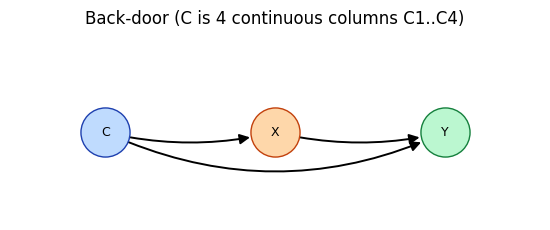

estimand: P(Y | do(X)) = Σ_{c}P(Y | C, X) P(C)
data: (20000, 6) ['C1', 'C2', 'C3', 'C4', 'X', 'Y']


In [3]:
scm, X, Y = example_SCM.BD_SCM(seednum=42, d=4)
G, X, Y = identify.preprocess_GXY_for_ID(scm.graph, X, Y)
draw_admg(G, X, Y, title="Back-door (C is 4 continuous columns C1..C4)")
print("estimand:", idq(G, X, Y))

obs = scm.generate_observational_samples(20000, seed=42)
print("data:", obs.shape, list(obs.columns))

In [4]:
ate = estimate(G, X, Y, np.array([1]), obs, cluster=["C"])
truth = statmodules.ground_truth(scm, X, Y, np.array([1]))

for est in ate:
    show(est, ate[est])
show("truth", truth)

OM     {(0,): 0.419, (1,): 0.583}
IPW    {(0,): 0.471, (1,): 0.6}
DML    {(0,): 0.471, (1,): 0.6}
truth  {(0,): 0.387, (1,): 0.574}


Read the keys as treatment values: `(0,)` is `do(X=0)`, `(1,)` is `do(X=1)`. All
three estimators land near the ground truth; the plug-in **OM** is closest here, and
the gaps shrink with more data.

**What the three estimators are:**

- **OM** — fit `E[Y | C, X]` (XGBoost), then average over `P(C)`: the g-formula
  plug-in.
- **IPW** — reweight observed outcomes. The weights are **not** raw
  inverse-propensity estimates: CausalPy solves a quadratic program per treatment
  step (`statmodules.sequential_quadratic_balancing`, via **OSQP**) for
  **minimum-norm balancing weights** — minimize `‖w‖²` subject to `Σ w = n` and the
  constraint that the weighted treated group matches the fitted outcome-model moment
  of the full (previous-step-weighted) sample, retrying with a small slack if the
  strict constraint is infeasible. Balancing avoids the instability of inverting
  small estimated propensities.
- **DML** — combine the outcome model and the balancing weights into a
  doubly-robust estimate (consistent if *either* nuisance is right), K-fold
  cross-fitted to remove overfitting bias.

## 2. Sequential treatments: `do(X1, X2)` on two outcomes

The mSBD graph from Tutorial 1: a time-ordered regime `X1, X2` acting on outcomes
`Y1, Y2`, with covariates `Z1, Z2` in between — and here too the covariates are
**clusters** (`Z1` is the columns `Z11..Z14`, `Z2` is `Z21..Z24`). The dispatcher
routes to the multi-outcome sequential estimator, and the result is keyed by the
**joint treatment value** `(x1, x2)`.

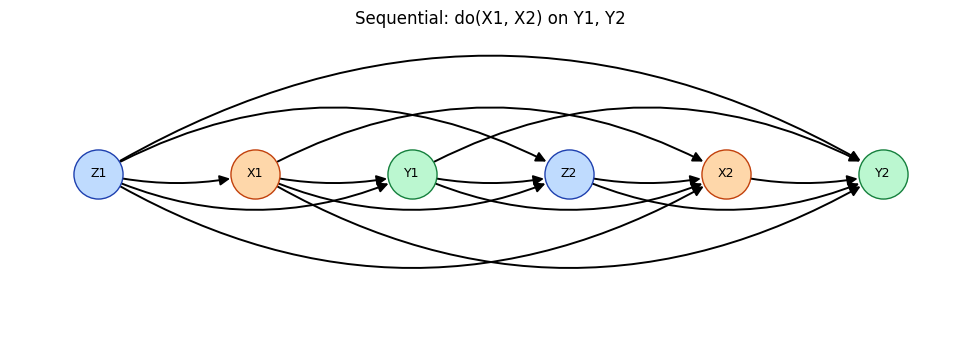

estimand: P(Y1, Y2 | do(X1, X2)) = Σ_{z1, z2} P(Y2 | X1, X2, Y1, Z1, Z2) P(Y1, Z2 | X1, Z1) P(Z1)
data: (20000, 12) ['Z11', 'Z12', 'Z13', 'Z14', 'X1', 'Y1', 'Z21', 'Z22', 'Z23', 'Z24', 'X2', 'Y2']


In [5]:
scm, X, Y = example_SCM.mSBD_SCM(seednum=42)
G, X, Y = identify.preprocess_GXY_for_ID(scm.graph, X, Y)
draw_admg(G, X, Y, title="Sequential: do(X1, X2) on Y1, Y2")
print("estimand:", idq(G, X, Y))

obs = scm.generate_observational_samples(20000, seed=42)
print("data:", obs.shape, list(obs.columns))

In [6]:
y_val = np.ones(len(Y)).astype(int)          # P(Y1=1, Y2=1 | do(x1, x2))
ate = estimate(G, X, Y, y_val, obs, cluster=["Z1", "Z2"])
truth = statmodules.ground_truth(scm, X, Y, y_val)

for est in ate:
    show(est, ate[est])
show("truth", truth)

OM     {(0, 0): 0.035, (0, 1): 0.041, (1, 0): 0.64, (1, 1): 0.938}
IPW    {(0, 0): 0.038, (0, 1): 0.027, (1, 0): 0.745, (1, 1): 0.945}
DML    {(0, 0): 0.038, (0, 1): 0.027, (1, 0): 0.745, (1, 1): 0.945}
truth  {(0, 0): 0.0, (0, 1): 0.015, (1, 0): 0.589, (1, 1): 0.973}


Each key is one joint intervention — `(1, 0)` means `do(X1=1, X2=0)` — and the
estimand is the probability that *both* outcomes are 1 under that regime. The
estimates track the ground truth across all four regimes; the **rare** regimes (true
probability near zero) carry the larger relative gaps, which is the usual
finite-sample behaviour.

## 3. A c-component effect: the Napkin graph

The Napkin effect was identified in Tutorial 1 as a **ratio** of marginalized
conditionals — no adjustment set exists. The dispatcher recognizes this **ratio
form** (`check_mSBD_ratio`) and routes it to a dedicated estimator
(`estimate_mSBD_ratio`): the numerator `Q[{X, Y}]` and denominator `Q[{X}]` are each
mSBD-expressible, so each is estimated with the same cross-fitted OM / balancing-IPW /
DML engine as above, pooled over the observed parent configurations, and the ratio is
taken once at the end. The result: **all three estimators**, here too.

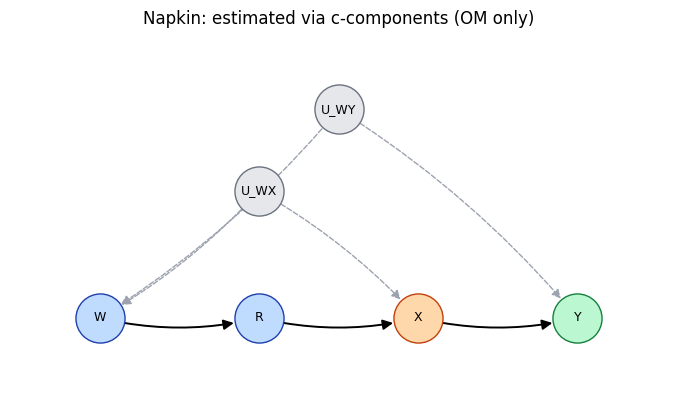

estimand: P({Y} | do({X})) = [[Σ_{w}P(X, Y | R, W) P(W)]/[Σ_{w}P(X | R, W) P(W)]]
data: (20000, 4) ['W', 'R', 'X', 'Y']


In [7]:
scm, X, Y = example_SCM.Napkin_SCM(seednum=42)
G, X, Y = identify.preprocess_GXY_for_ID(scm.graph, X, Y)
draw_admg(G, X, Y, title="Napkin: estimated via c-components (OM only)")
print("estimand:", idq(G, X, Y))

obs = scm.generate_observational_samples(20000, seed=42)
print("data:", obs.shape, list(obs.columns))

In [8]:
ate = estimate(G, X, Y, np.array([1]), obs, cluster=[])
truth = statmodules.ground_truth(scm, X, Y, np.array([1]))

for est in ate:
    show(est, ate[est])
show("truth", truth)

OM     {(0,): 0.874, (1,): 0.122}
IPW    {(0,): 0.88, (1,): 0.123}
DML    {(0,): 0.88, (1,): 0.123}
truth  {(0,): 0.875, (1,): 0.127}


All three estimators sit within a fraction of a percentage point of the ground
truth — the ratio decomposition lets the well-tested adjustment engine do all the
statistical work. The same route handles harder ratio-form graphs such as the
*nested* Napkin from Tutorial 1.

## 4. Front-door: the general c-component path

Front-door graphs have no adjustment set and no ratio form, so they fall through to
the **general c-component estimator**, which assembles the estimand from Q-factor
tables. That assembly is currently sound for the plug-in only, so the dispatcher runs
it in **outcome-model-only mode** — the returned dictionary has just `OM`, and the
experimental paths raise a clear `NotImplementedError` rather than returning a wrong
number. Here `Z` and `X` are one-dimensional binary variables (`dZ=1`), and the
confounder `C` is a small binary cluster (`dC=3`).

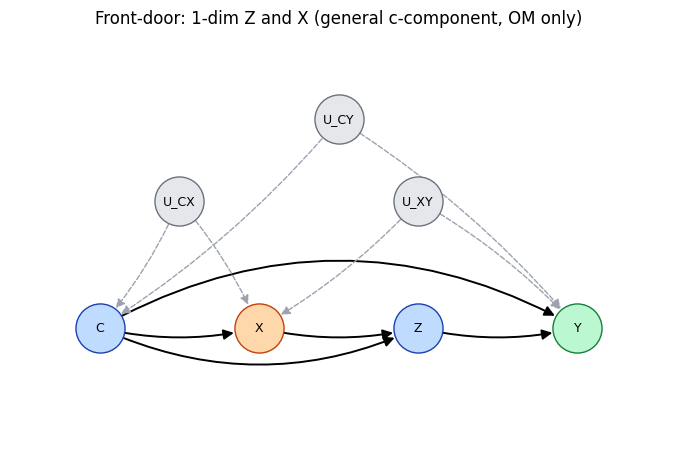

estimand: P(Y | do(X)) = Σ_{c, z} P(Z | C, X)P(C) Σ_{x} P(Y | C, X, Z)P(X | C)
data: (20000, 6) ['C1', 'C2', 'C3', 'X', 'Z1', 'Y']


In [9]:
scm, X, Y = example_SCM.FD_SCM(seednum=42, dC=3, dZ=1)
G, X, Y = identify.preprocess_GXY_for_ID(scm.graph, X, Y)
draw_admg(G, X, Y, title="Front-door: 1-dim Z and X (general c-component, OM only)")
print("estimand:", idq(G, X, Y))

obs = scm.generate_observational_samples(20000, seed=42)
print("data:", obs.shape, list(obs.columns))

In [10]:
ate = estimate(G, X, Y, np.array([1]), obs, cluster=["C", "Z"])
truth = statmodules.ground_truth(scm, X, Y, np.array([1]))

for est in ate:
    show(est, ate[est])
show("truth", truth)

OM     {(0,): 0.321, (1,): 0.309}
truth  {(0,): 0.319, (1,): 0.305}


On this discrete graph the plug-in tracks the truth closely. With *continuous*
covariates the general path becomes slow (it enumerates observed configurations) —
that is the main open limitation of the experimental c-component machinery.

---

**Which estimator do I get?**

| graph class | route | estimators |
|---|---|---|
| back-door | `est_mSBD.estimate_BD` | OM, IPW, DML |
| sequential back-door (single outcome) | `est_mSBD.estimate_SBD` | OM, IPW, DML |
| sequential back-door (multiple outcomes) | `est_mSBD.estimate_mSBD_y` | OM, IPW, DML |
| ratio-form c-component (Napkin-class) | `est_general.estimate_mSBD_ratio` | OM, IPW, DML |
| other c-component (e.g. front-door) | `est_general.estimate_*` | OM only (experimental) |

**Next:** [Tutorial 3 — Custom SCM](03_custom_scm.ipynb) builds a structural causal
model from scratch and runs this same identify → estimate → validate loop on it.